In [1]:
#imports
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import gamma
from numpy.linalg import inv, slogdet
from matplotlib.patches import Ellipse

# Image Generation 

### Equation 1:

$$
\text{image} = z \times \left( \sum_{i} \text{activation}_{i} \times \text{basis}_{i} \right) + \text{noise}
$$

This is the mechanistic process that leads to image generation. It states that as images is created by taking weighted sum of basis funmctions (columns of Matrix **A**) that are scaled by activation values (from  **y**), multiplied by a contrast scaling factor z, and then adding noise

### Equation 2:

$$
P(\mathbf{x} | \mathbf{y}, z) = \mathcal{N} \left( \mathbf{x} ; z \mathbf{A} \mathbf{y}, \sigma_x^2 \mathbf{I} \right)
$$

This is the generative model for the image patches- it defines the probability distribution of the observed pixel values (**x**) given the latent varaibles (activations of basis functions given by vector **y**), and contrast z. It is a multivariate normal distribution.

Equation 1 described the mechanism for image generation whilst equation 2 is a probabilistic generation process given **y** and z. 

### Equation 3: 

$$
P(\mathbf{y}) = \mathcal{N} \left( \mathbf{y} ; 0, \mathbf{C} \right)
$$

This is the prior over the latent variables (activations of the brain). With no stimulus presentation, it describes how likely different sets of activations are. 0 mean so with no stimulus we expect no activations. Covarianc matrix C captures relationships between different neurons (columns of matrix **A**, which are the basis functions and in this sense represent the neurons)

Neurons with overlapping receptive fields (or basis functions that capture similar features) will have covariances that indicate they are likely to be activated together- for example neurons sensitive to edges of the same orientation might have correlated activations.


## How do we Generate the Image?

For each image we generate, we:

1. __Sample from the prior (equation 3):__

Sampling **y**, the activation of the neurons, from the prior distribution p(**y**). This gives us a set of activation values for the basis functions.

2. __Generating the image (equation 1):__

We multiply each activation **y**~i~ by its corresponding basis function (columns of matrix **A**) and sum these weighted basis functions- this will give us a linear combination of features that forms the image.

We then multiply this sum by the contrast variable z- this controls the global contrast of the image

__Finally, Gaussian Noise is added to simulate imperfect observation or sensory noise__

In [2]:
np.random.seed(20)

In [ ]:
model_parameters = scipy.io.loadmat('model_parameters.mat')

# model parameters
Dx = model_parameters['Dx'][0,0]  # Number of observed variables/pixels (16x16 = 256)
Dy = model_parameters['Dy'][0,0]  # Number of latent variables/filters
A = model_parameters['A']         # Filter bank (Dx x Dy)
rho = model_parameters['rho']     # Prior covariance matrix (Dy x Dy)
sigmaX = model_parameters['sigmaX'][0,0]  # Observation noise


# z model parameters
kGam = model_parameters['kGam'][0,0]     # Shape parameter of Gamma distribution
thGam = model_parameters['thGam'][0,0]   # Scale parameter of Gamma distribution

In [4]:
percentiles = [0.01, 0.05, 0.2, 0.5]
z_values = gamma.ppf(percentiles, a=kGam, scale=thGam)
print("Selected z values at given percentiles:", z_values)

Selected z values at given percentiles: [0.29710948 0.71072302 1.64877662 3.35669398]


In [ ]:
contrast_values = [ 0,1.92255753,3.35669398,5.38526906,13.27670414,28.47325542,80.92313497]



In [ ]:
# generate 3 different sets of latent activations y and x (noise)
mu_y = np.zeros(Dy)  # mu
y_set = [np.random.multivariate_normal(mu_y, rho) for _ in range(3)]  
x_set = [np.random.normal(0, sigmaX, Dx) for _ in range(3)]  # noise terms

### Scaling Pixel Intensities and Image Generation Code

In [ ]:
# global min and max pixel values for consistent scaling across all images
min_val = np.inf
max_val = -np.inf

# calc the global min and max across all images for consistent scaling
for row, (y, x) in enumerate(zip(y_set, x_set)):
    for z in contrast_values:
        image = z * np.dot(A, y) + x  # use the same x (noise) for each contrast in the row
        min_val = min(min_val, np.min(image))
        max_val = max(max_val, np.max(image))

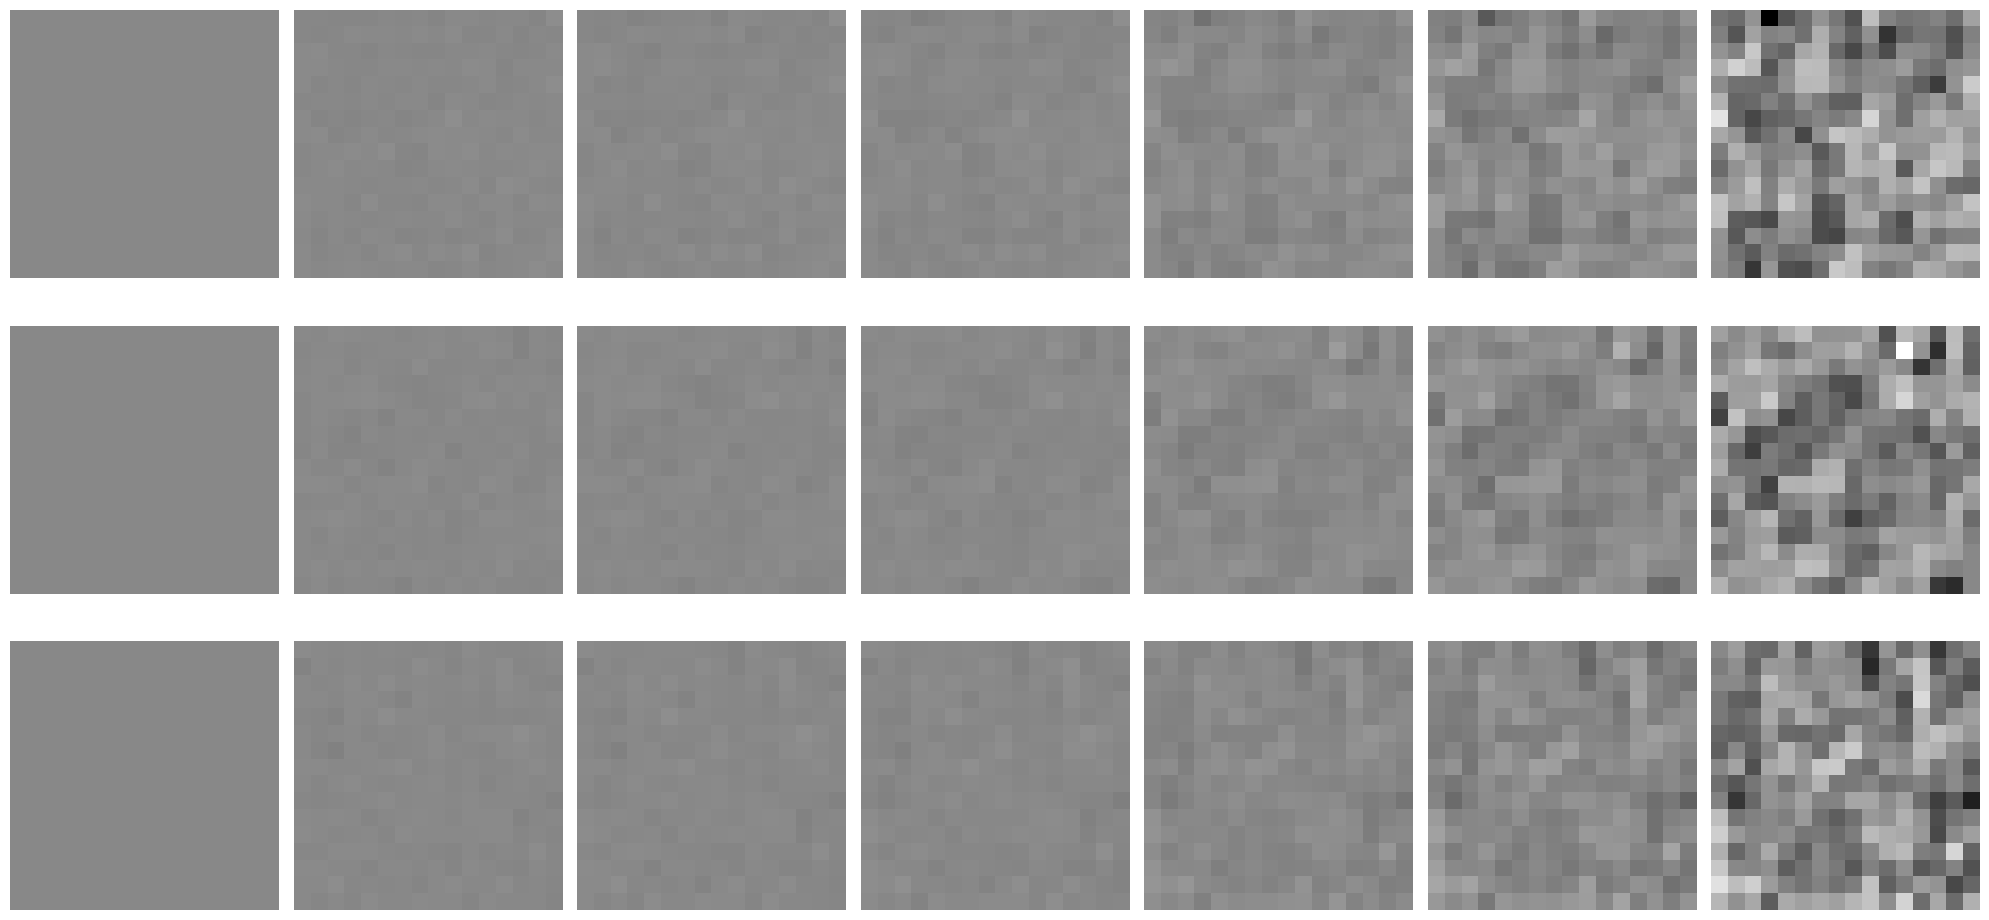

In [ ]:

fig, axes = plt.subplots(3, 7, figsize=(20, 10))

# loop over each set of latent activations y and corresponding noise x (for each row)
for row, (y, x) in enumerate(zip(y_set, x_set)):

    for col, z in enumerate(contrast_values):
        # eqn 2: x = z * A * y + noise 
        if z == 0:
            image = z * np.dot(A, y)
        else:
            image = z * np.dot(A, y) + x
        

        image_patch = image.reshape(16, 16)
        

        ax = axes[row, col]
        ax.imshow(image_patch, cmap='gray', vmin=min_val, vmax=max_val) 
        ax.axis('off') 

plt.tight_layout()
plt.show()

### Sanity Check - Ensuring the generation process is occuring as per the implementation

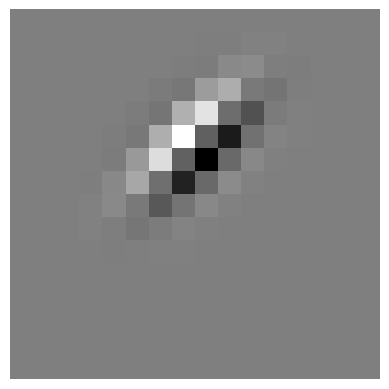

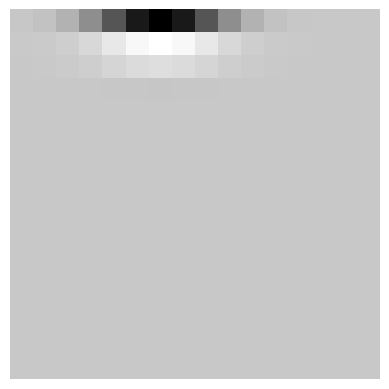

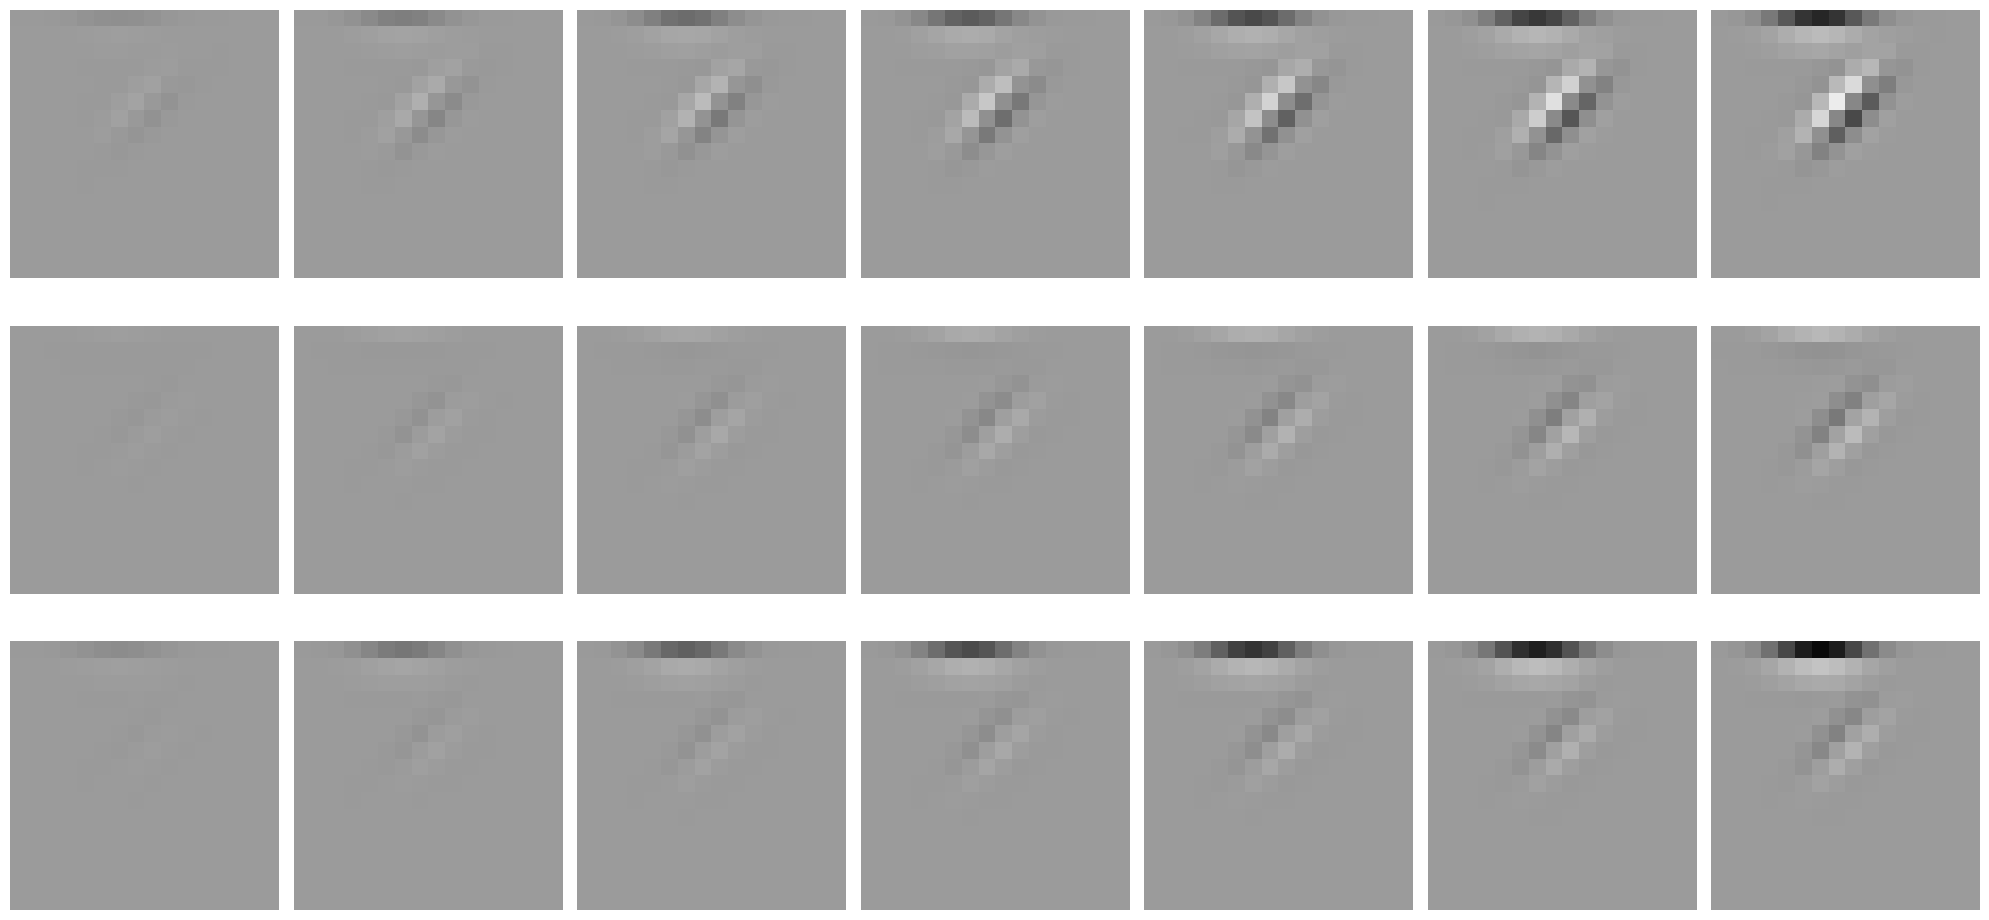

In [ ]:
# sanity check: zero out all but 2 basis components
non_zero_indices = [50, 75]

for idx in non_zero_indices:
    plt.imshow(A[:, idx].reshape(16, 16), cmap='gray')
    plt.axis('off')
    plt.show()

modified_y_set = []
for y in y_set:
    modified_y = np.zeros_like(y)
    modified_y[non_zero_indices] = y[non_zero_indices]
    modified_y_set.append(modified_y)

zero_noise_set = [np.zeros_like(x) for x in x_set]
sanity_contrast_values = np.linspace(1, 10, 7)

# global range for consistent colormap
min_val, max_val = np.inf, -np.inf
for y, x in zip(modified_y_set, x_set):
    for z in sanity_contrast_values:
        image = z * np.dot(A, y) + x
        min_val = min(min_val, np.min(image))
        max_val = max(max_val, np.max(image))

sanity_num_contrasts = len(sanity_contrast_values)
fig, axes = plt.subplots(3, sanity_num_contrasts, figsize=(20, 10))

for row, (y, x) in enumerate(zip(modified_y_set, zero_noise_set)):
    for col, z in enumerate(sanity_contrast_values):
        image = (z * np.dot(A, y) + x).reshape(16, 16)
        axes[row, col].imshow(image, cmap='gray', vmin=min_val, vmax=max_val)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [11]:
print(min_val)

-4.859716115635749


# Inference

In [12]:
A.shape[1]

248

### Functions

In [ ]:
def normpdfln(x, mean, cov):
    """Log pdf of multivariate normal."""
    D = x.shape[0]
    x_m = x - mean
    sign, logdet = slogdet(cov)
    inv_cov = inv(cov)
    return -0.5 * (x_m.T @ inv_cov @ x_m + D * np.log(2 * np.pi) + logdet)


def calc_npz_x(z, x, Sigma0, ACAT, x0, kGam, thGam):
    """Negative log-posterior of z given x."""
    if z <= 0:
        return np.inf
    log_Pz = gamma.logpdf(z, a=kGam, scale=thGam)
    Sigma_x = Sigma0 + (z ** 2) * ACAT
    log_Px_z = normpdfln(x, x0, Sigma_x)
    return -(log_Pz + log_Px_z)


def get_pz_x_max(x, Sigma0, ACAT, x0, kGam, thGam):
    """Find mode of p(z|x) and bracket [zMin, zMax] where log-posterior is within log(1000) of peak."""
    z0 = (kGam - 1) * thGam if kGam > 1 else thGam * 1e-3
    if z0 <= 0:
        z0 = thGam * 1e-3

    res = minimize(calc_npz_x, z0, args=(x, Sigma0, ACAT, x0, kGam, thGam),
                   bounds=[(1e-8, None)], method='L-BFGS-B')
    z = res.x[0]
    lPz_xMax = -res.fun
    threshold = 1000

    # expand left
    g = 0.8
    zMin = g * z
    while (-calc_npz_x(zMin, x, Sigma0, ACAT, x0, kGam, thGam) > lPz_xMax - np.log(threshold)) and (g > 0):
        g -= 0.1
        zMin = g * z

    # expand right
    g = 1 + (1 - g)
    zMax = g * z
    while -calc_npz_x(zMax, x, Sigma0, ACAT, x0, kGam, thGam) > lPz_xMax - np.log(threshold):
        g += 0.1
        zMax = g * z

    return z, zMin, zMax


def infer_y_and_z(x, A, rho, kGam, thGam, sigmaX, Dz=1000):
    """Posterior inference over y and z for a single image x. Grid integration over z."""
    Dx, Dy = A.shape
    rhoInv = inv(rho)
    ACAT = A @ rho @ A.T
    Sigma0 = np.eye(Dx) * (sigmaX ** 2)
    x0 = np.zeros(Dx)

    z_mode, z_min, z_max = get_pz_x_max(x, Sigma0, ACAT, x0, kGam, thGam)
    zRange = np.linspace(z_min, z_max, Dz)
    dz = zRange[1] - zRange[0]

    lPz_x = np.full(Dz, -np.inf)
    Sigma = np.zeros((Dy, Dy, Dz))
    mu = np.zeros((Dy, Dz))

    # p(z|x) on grid
    for zi, z in enumerate(zRange):
        lPz_x[zi] = gamma.logpdf(z, a=kGam, scale=thGam) + normpdfln(x, x0, Sigma0 + (z**2) * ACAT)

    Pz_x = np.exp(lPz_x - np.max(lPz_x))
    Pz_x /= (np.sum(Pz_x) * dz)

    # p(y|x,z) for each z
    for zi, z in enumerate(zRange):
        Sigma_z = inv(rhoInv + (z**2 / sigmaX**2) * (A.T @ A))
        mu[:, zi] = (z / sigmaX**2) * Sigma_z @ A.T @ x
        Sigma[:, :, zi] = Sigma_z

    return mu, Sigma, Pz_x, zRange, dz

### Inference on __z__

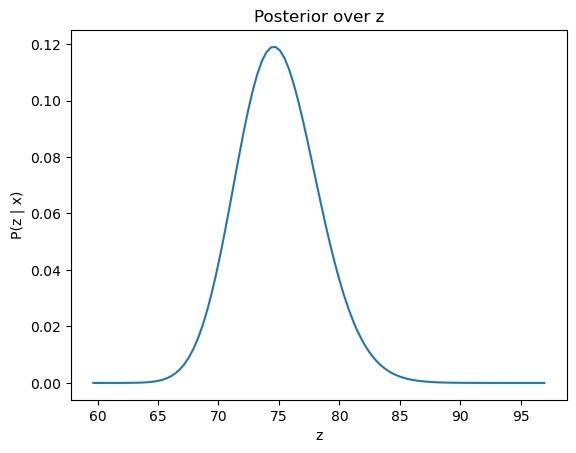

1.0

In [ ]:
# select one image at a specific contrast
y_true = y_set[0]
x_noise = x_set[0]
z_contrast = contrast_values[6]

x_obs = z_contrast * A @ y_true + x_noise

mu, Sigma, Pz_x, zRange, dz = infer_y_and_z(x_obs, A, rho, kGam, thGam, sigmaX, Dz=100)

plt.figure()
plt.plot(zRange, Pz_x)
plt.xlabel('z')
plt.ylabel('P(z | x)')
plt.title('Posterior over z')
plt.show()

print("∫ p(z|x) dz =", Pz_x.sum() * dz)

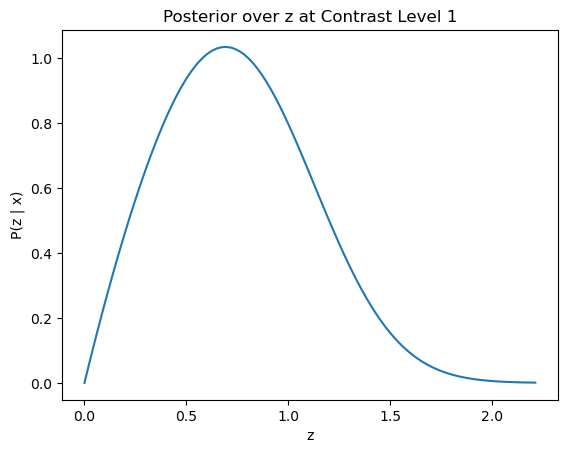

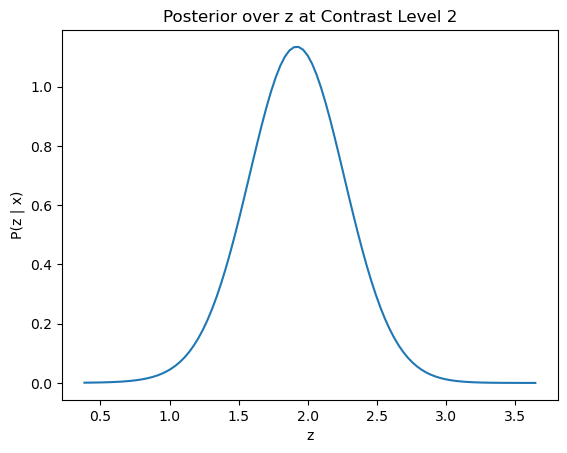

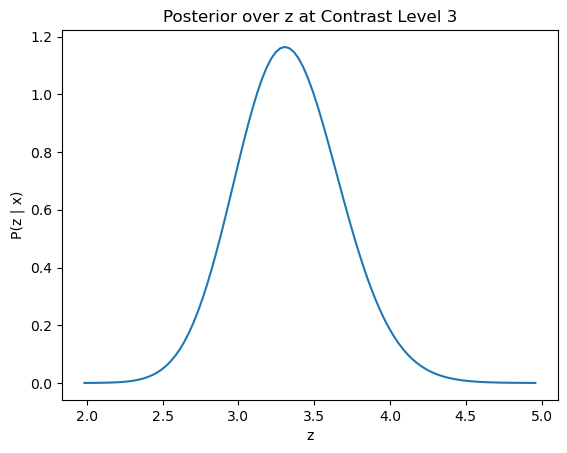

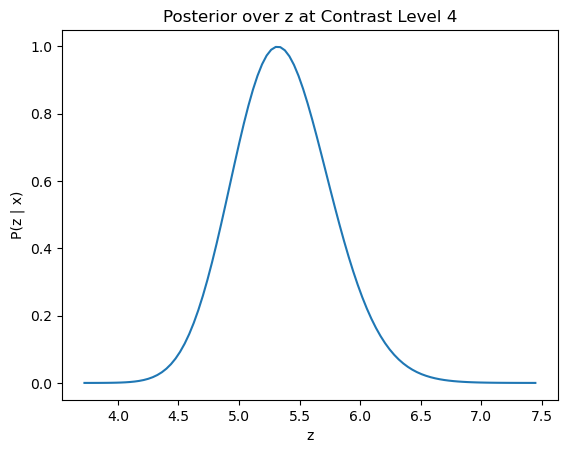

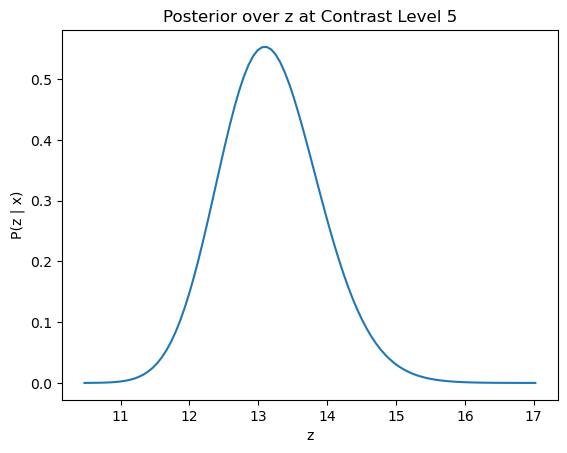

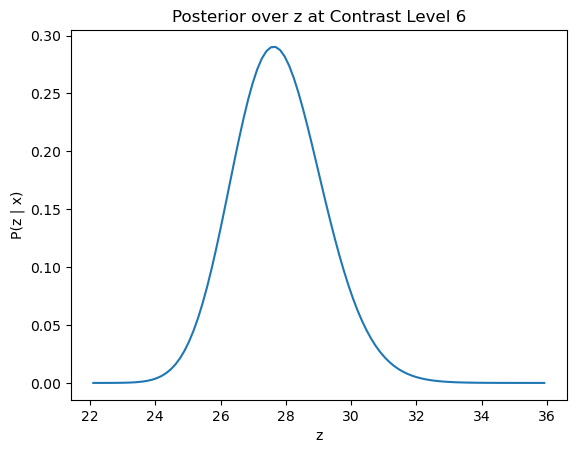

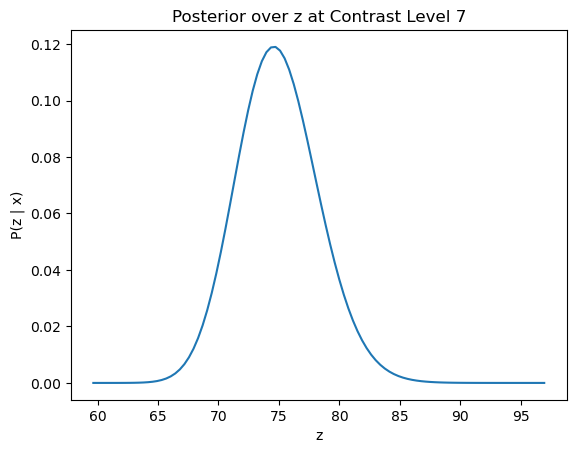

In [ ]:
for idx, z_contrast in enumerate(contrast_values):
    x_obs = z_contrast * A @ y_true + x_noise
    mu, Sigma, Pz_x, zRange, dz = infer_y_and_z(x_obs, A, rho, kGam, thGam, sigmaX, Dz=100)

    plt.figure()
    plt.plot(zRange, Pz_x)
    plt.xlabel('z')
    plt.ylabel('P(z | x)')
    plt.title(f'p(z|x), contrast level {idx+1}')
    plt.show()

### Plotting posterior sampling activity of two neurons

In [ ]:
def plot_gaussian_ellipse(ax, mean, cov, edgecolor='blue', linestyle='-', label=None):
    """Plot 1-sigma covariance ellipse for a 2D Gaussian."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(vals)

    ellipse = Ellipse(xy=mean, width=width, height=height, angle=theta,
                      edgecolor=edgecolor, fc='None', lw=2, linestyle=linestyle, label=label)
    ax.add_patch(ellipse)

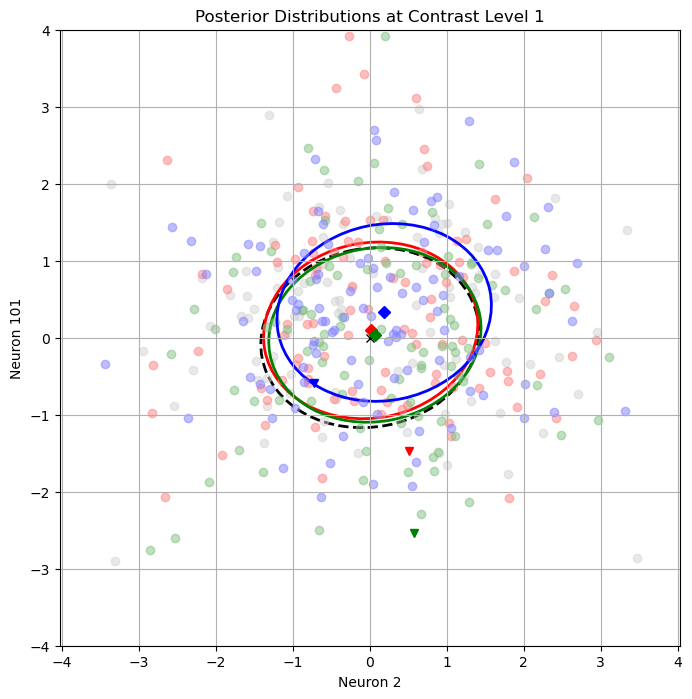

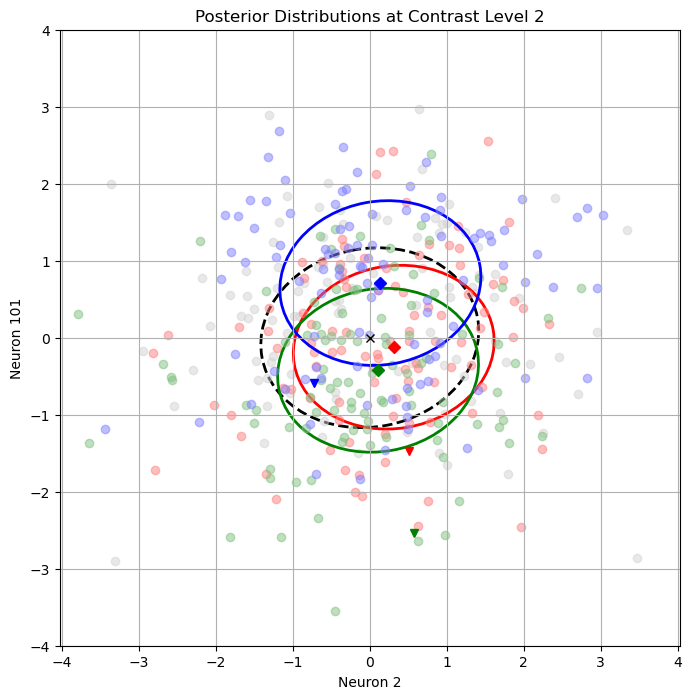

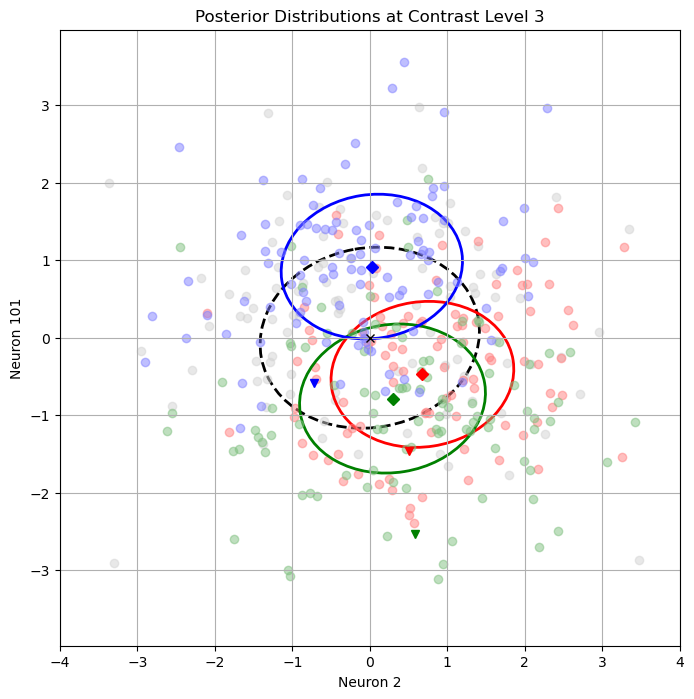

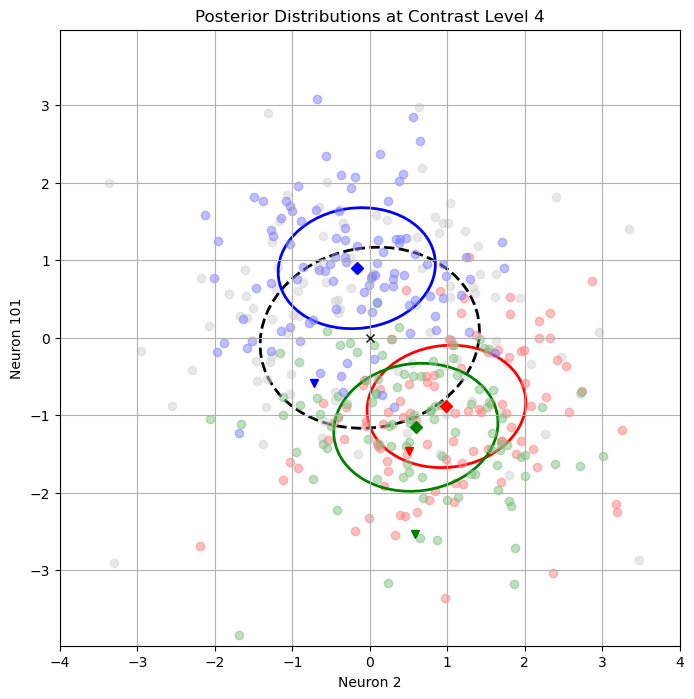

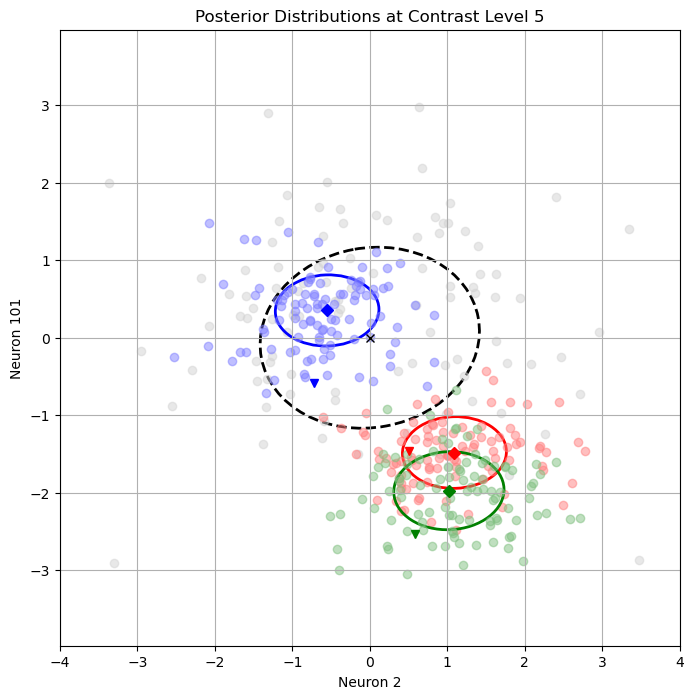

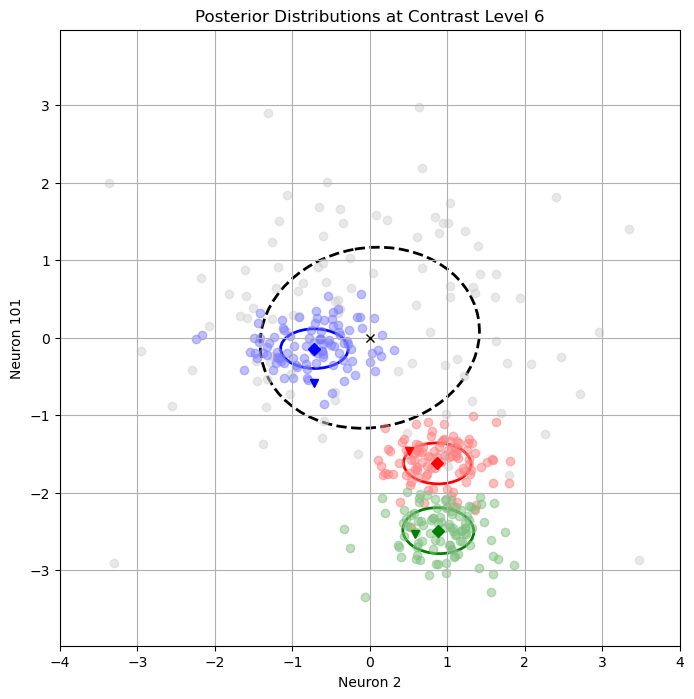

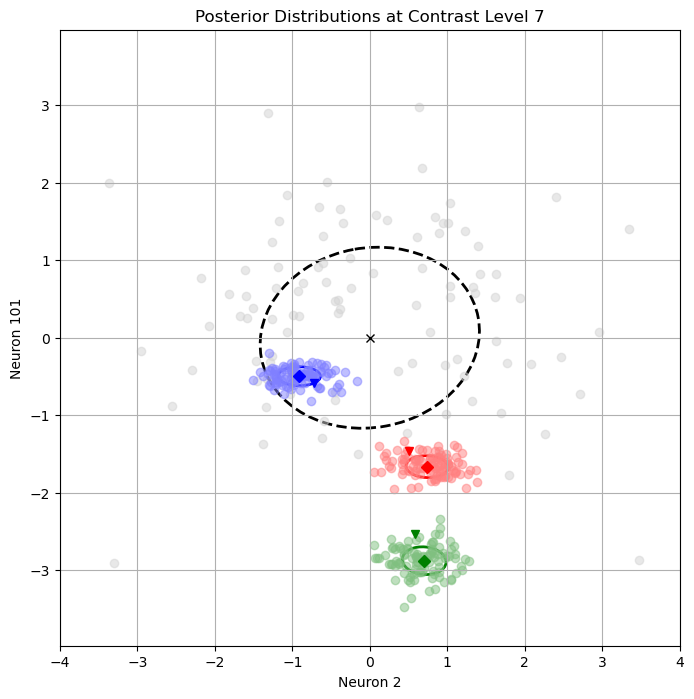

In [ ]:
import matplotlib.colors as mcolors

def lighten_color(color, amount=0.5):
    """Blend color toward white."""
    c = np.array(mcolors.to_rgb(mcolors.cnames.get(color, color)))
    return np.clip(c + (1.0 - c) * amount, 0, 1)

colors = ['red', 'green', 'blue']
neuron_indices = [1, 100]

# prior in 2D subspace
rho_2d = rho[np.ix_(neuron_indices, neuron_indices)]
mu_prior = np.zeros(2)
samples_prior = np.random.multivariate_normal(mu_prior, rho_2d, size=100)

for contrast_idx, z_contrast in enumerate(contrast_values):
    fig, ax = plt.subplots(figsize=(8, 8))

    plot_gaussian_ellipse(ax, mu_prior, rho_2d, edgecolor='black', linestyle='--', label='Prior')
    ax.plot(*mu_prior, 'kx', label='Prior Mean')
    ax.scatter(samples_prior[:, 0], samples_prior[:, 1], color='lightgrey', alpha=0.5, label='Prior Samples')

    for image_idx, (y_true, x_noise) in enumerate(zip(y_set, x_set)):
        x_obs = z_contrast * A @ y_true + x_noise
        mu, Sigma, Pz_x, zRange, dz = infer_y_and_z(x_obs, A, rho, kGam, thGam, sigmaX, Dz=100)

        # marginalise over z
        mu_yx = np.zeros(Dy)
        Sigma_yx = np.zeros((Dy, Dy))
        for zi in range(len(zRange)):
            mu_yx += Pz_x[zi] * mu[:, zi] * dz
        for zi in range(len(zRange)):
            diff = mu[:, zi] - mu_yx
            Sigma_yx += Pz_x[zi] * (Sigma[:, :, zi] + np.outer(diff, diff)) * dz

        mu_2d = mu_yx[neuron_indices]
        Sigma_2d = Sigma_yx[np.ix_(neuron_indices, neuron_indices)]

        plot_gaussian_ellipse(ax, mu_2d, Sigma_2d, edgecolor=colors[image_idx], label=f'Posterior {image_idx+1}')
        ax.plot(mu_2d[0], mu_2d[1], marker='D', color=colors[image_idx])
        ax.plot(y_true[neuron_indices[0]], y_true[neuron_indices[1]], marker='v', color=colors[image_idx])

        samples_posterior = np.random.multivariate_normal(mu_2d, Sigma_2d, size=100)
        ax.scatter(samples_posterior[:, 0], samples_posterior[:, 1],
                   color=lighten_color(colors[image_idx], 0.5), alpha=0.5)

    ax.set_title(f'Contrast level {contrast_idx+1}')
    ax.set_xlabel(f'Neuron {neuron_indices[0]+1}')
    ax.set_ylabel(f'Neuron {neuron_indices[1]+1}')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# PCA

## PCA on posterior

### Imports

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting
from sklearn.decomposition import PCA
import numpy as np


### Generating Samples from the Posterior

We have 248 basis functions
There are 3 images, at 7 contrast levels
We take 100 samples of each image at each contrast level
This puts us in the space R^ 248 x 2100

We want to use PCA to reduce this to the space R^ 248 x 248 with PCA ie 248 basis functions and 248 principal components

We want the top principal components. Eg for 2 PC, we reduce to the space R^2x248


In [19]:
#matrix to store 248 basis functions x 2100 posterior samples
Y_data = np.zeros((Dy, 3*7*100)) #Dy rows, 3 images, 7 contrasts, 100 samples

#counter to fill Y_data
data_idx = 0

#for each contrast level and image, compute posterior and take 100 samples
for z_contrast in contrast_values:
    for y_true, x_noise in zip(y_set, x_set):
        #Generate observed image:
        x_obs = z_contrast * A @ y_true + x_noise

        #perform posteriori inference to get posterior mean and covariance
        mu, Sigma, Pz_x, zRange, dz = infer_y_and_z(x_obs, A, rho, kGam, thGam, sigmaX, Dz=100)

        #marginalise over z to get posterior over y: P(y|x)

        # Marginalize over z to get the posterior mean and covariance P(y | x)
        mu_yx = np.zeros(Dy)
        Sigma_yx = np.zeros((Dy, Dy))
        
        for zi in range(len(zRange)):
            mu_yx += Pz_x[zi] * mu[:, zi] * dz
        for zi in range(len(zRange)):
            diff = mu[:, zi] - mu_yx
            Sigma_yx += Pz_x[zi] * (Sigma[:, :, zi] + np.outer(diff, diff)) * dz

        
        #we have posterior P(y|x) mean and covar for an image at certain contrast level- now we sample 100 times:
        for _ in range(100):
             # Generate a sample from the multivariate normal distribution with mean `mu_yx` and covariance `Sigma_yx`
            y_sample = np.random.multivariate_normal(mu_yx, Sigma_yx)
            
            # Fill in the column in Y_data with this posterior sample
            Y_data[:, data_idx] = y_sample
            data_idx += 1

# Y_data, we expect 248 x 2100
print(f"Shape of Y_data: {Y_data.shape}")
            

Shape of Y_data: (248, 2100)


### PCA across all 248 components

##### After centering the data by subtracting the mean activation vector, the PCA algorithm was applied.

Here we do PCA across all 248 components, as the original data resides in 248 dimensional space- this gives a full visualisation of the cumulative variance approaching 100%.

In [ ]:
# mean Subtraction
mu_Y = np.mean(Y_data, axis=1, keepdims=True)  # compute the mean across samples (shape 248x1)
Y_centered = Y_data - mu_Y  # subtract mean activation vector from each sample (result: 248 x 2100)

# PCA on the centered data
pca_248_ydata = PCA(n_components=248)
pca_248_ydata.fit(Y_centered.T) 

PCA(n_components=248)

### Cumulative Explained Variance

#####  PCA algorithm was applied to capture the directions in the data that explain the most variance, as number of principal components increase. Using 248 components gives a full visualsation of explained variance approaching 100%


[3.04052968e-01 1.54002010e-01 8.98216854e-02 4.40943116e-02
 2.95079854e-02 2.64708367e-02 2.10643092e-02 1.85886194e-02
 1.65990236e-02 1.55005154e-02 1.18937268e-02 1.11827272e-02
 9.66185857e-03 8.73578704e-03 8.37417683e-03 6.85348900e-03
 6.57903617e-03 5.76078302e-03 5.51565143e-03 5.11490066e-03
 4.96663278e-03 4.74761931e-03 3.95839393e-03 3.90047831e-03
 3.59716810e-03 3.49237333e-03 3.37798069e-03 3.02543051e-03
 2.82974837e-03 2.76279480e-03 2.59569977e-03 2.46351994e-03
 2.43246049e-03 2.31526189e-03 2.26784610e-03 2.23532604e-03
 2.16738297e-03 2.14655865e-03 2.11697538e-03 2.07472626e-03
 2.04852748e-03 2.04231816e-03 1.99530299e-03 1.95645571e-03
 1.94909551e-03 1.90880875e-03 1.89892311e-03 1.89123402e-03
 1.87863890e-03 1.85398526e-03 1.84644927e-03 1.82583657e-03
 1.78640557e-03 1.77372129e-03 1.75814923e-03 1.74877814e-03
 1.72703281e-03 1.70575259e-03 1.70397710e-03 1.68854382e-03
 1.67079024e-03 1.65033007e-03 1.64560164e-03 1.63409048e-03
 1.61676225e-03 1.607731

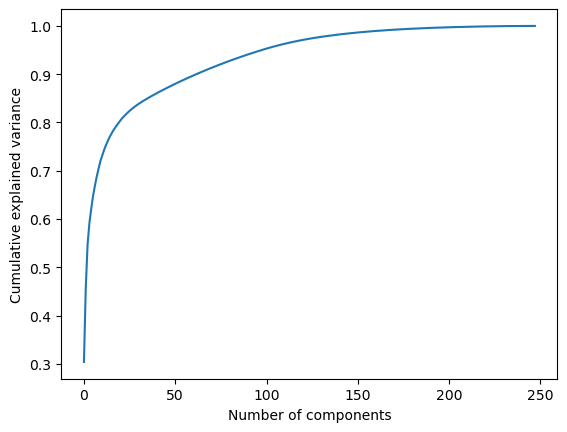

In [21]:
print(pca_248_ydata.explained_variance_ratio_)
plt.plot(np.cumsum(pca_248_ydata.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()


### Thresholds for Dimensionality Reduction

The explained variance ratio was then used to capture how many principal components were needed to capture specific percentages of the total variance. Specifically we set thresholds of 90% and 95% of total variance and looked at how many principal components would be required to meet these thresholds

In [ ]:

ydata_explained_variance_ratios = pca_248_ydata.explained_variance_ratio_

# cumulative sum of explained variance
cumulative_variance = np.cumsum(ydata_explained_variance_ratios)

# number of components that capture 90% of the variance
threshold = 0.90 
n_components_90 = np.argmax(cumulative_variance >= threshold) + 1

# number of components that capture 95% of the variance
threshold_95 = 0.95
n_components_95 = np.argmax(cumulative_variance >= threshold_95) + 1

print("Explained variance ratios by component:", ydata_explained_variance_ratios)
print("Cumulative explained variance:", cumulative_variance)
print(f"Number of components needed to capture 90% of the variance: {n_components_90}")
print(f"Number of components needed to capture 95% of the variance: {n_components_95}")

Explained variance ratios by component: [3.04052968e-01 1.54002010e-01 8.98216854e-02 4.40943116e-02
 2.95079854e-02 2.64708367e-02 2.10643092e-02 1.85886194e-02
 1.65990236e-02 1.55005154e-02 1.18937268e-02 1.11827272e-02
 9.66185857e-03 8.73578704e-03 8.37417683e-03 6.85348900e-03
 6.57903617e-03 5.76078302e-03 5.51565143e-03 5.11490066e-03
 4.96663278e-03 4.74761931e-03 3.95839393e-03 3.90047831e-03
 3.59716810e-03 3.49237333e-03 3.37798069e-03 3.02543051e-03
 2.82974837e-03 2.76279480e-03 2.59569977e-03 2.46351994e-03
 2.43246049e-03 2.31526189e-03 2.26784610e-03 2.23532604e-03
 2.16738297e-03 2.14655865e-03 2.11697538e-03 2.07472626e-03
 2.04852748e-03 2.04231816e-03 1.99530299e-03 1.95645571e-03
 1.94909551e-03 1.90880875e-03 1.89892311e-03 1.89123402e-03
 1.87863890e-03 1.85398526e-03 1.84644927e-03 1.82583657e-03
 1.78640557e-03 1.77372129e-03 1.75814923e-03 1.74877814e-03
 1.72703281e-03 1.70575259e-03 1.70397710e-03 1.68854382e-03
 1.67079024e-03 1.65033007e-03 1.64560164e-03

### Data Plotted on top 2 Principal Components

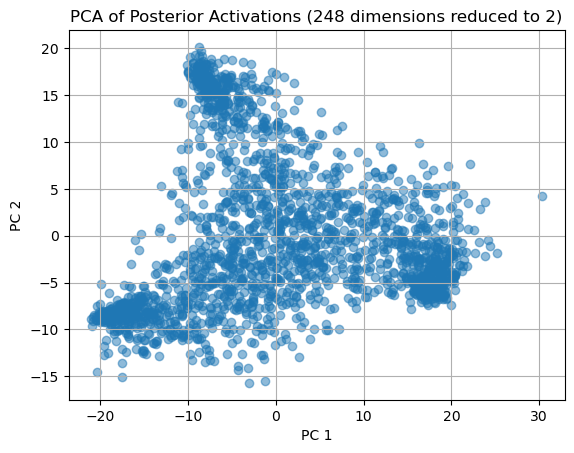

In [ ]:
# apply PCA to reduce dimensionality from 248 to 2
pca_2_ydata = PCA(n_components=2)  # keep the top 2 principal components
Y_pca_2 = pca_2_ydata.fit_transform(Y_centered.T)  



plt.scatter(Y_pca_2[:, 0], Y_pca_2[:, 1], alpha=0.5)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('PCA of Posterior Activations (248 dimensions reduced to 2)')
plt.grid(True)
plt.show()

### Data Plotted on top 3 Principal Components

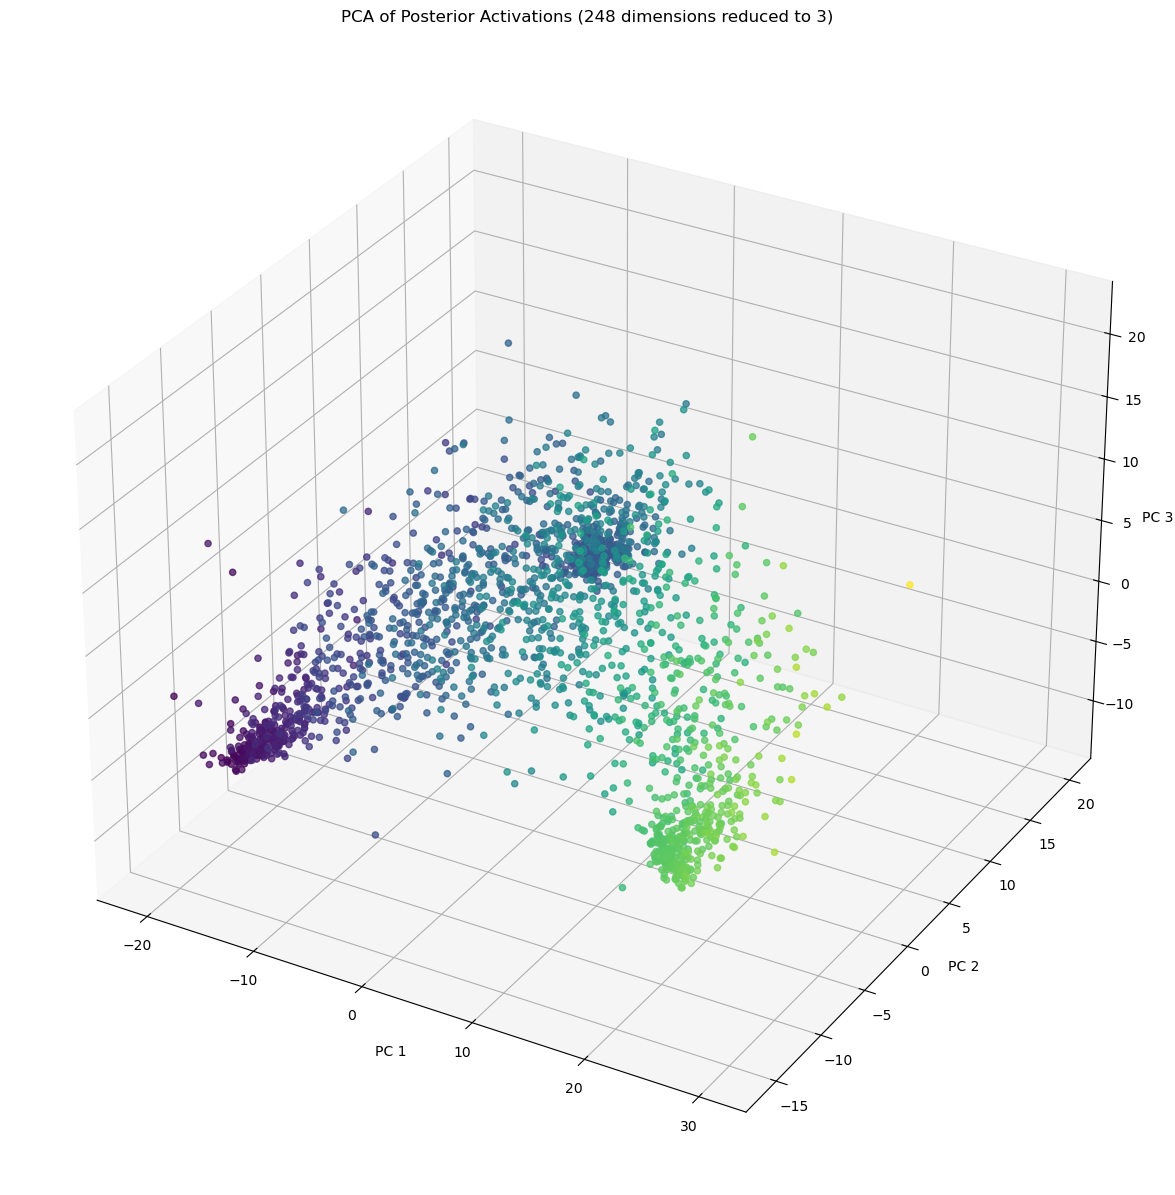

In [ ]:

pca_3_ydata = PCA(n_components=3)  # keep the top 3 principal components
Y_pca_3 = pca_3_ydata.fit_transform(Y_centered.T) 

# Y_pca now contains the 2100 observations in the reduced 3D space

# create 3D scatter plot of the top 3 PC
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

# plot the data in 3D
ax.scatter(Y_pca_3[:, 0], Y_pca_3[:, 1], Y_pca_3[:, 2], alpha=0.75, c=Y_pca_3[:, 0], cmap='viridis')

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')

plt.title('PCA of Posterior Activations (248 dimensions reduced to 3)')
plt.show()

## PCA on True Latent Activations

Previously we used the inferred **y** using equations 4 and 5 from Orban et al. to identify the parameters of the latent activation distributions.

We now compare results using the true latents, from y_set, which were actually used to generate the images. By taking samples from the true **y**, we can see how as the number of samples increases, the inferred values of the inferred y values converge to the true latent variables. 

Visualisation is once again done using PCA. Similarity will verify that the posterior is able to correctly learn the latents. 

In [ ]:

Y_samples = np.zeros((Dy, 3*7*100))  

# counter to fill in the Y_samples matrix
data_idx = 0

# for each contrast level and image, sample from the posterior around the true y
for z_contrast in contrast_values:
    for y_true in y_set:
        # here we assume the true y from y_set is the mean of the distribution
        # use the covariance (rho) to take samples
        for _ in range(100):
            # geb samples from the true y distribution (mean = y_true, covariance = rho)
            y_sample = np.random.multivariate_normal(mean=y_true, cov=rho)
            

            Y_samples[:, data_idx] = y_sample
            data_idx += 1

# Y_samples is now a 248 x 2100 matrix 
print(f"Shape of Y_samples: {Y_samples.shape}")


Shape of Y_samples: (248, 2100)


In [ ]:

mu_Y_samples = np.mean(Y_samples, axis=1, keepdims=True)  
Y_centered_samples = Y_samples - mu_Y_samples  

# PCA on the centered data
pca_248_ysamples = PCA(n_components=248)
pca_248_ysamples.fit(Y_centered_samples.T) 

PCA(n_components=248)

[3.10614369e-01 1.73116975e-01 6.44202486e-02 4.12465879e-02
 3.64034090e-02 2.89274854e-02 2.19874890e-02 1.85408417e-02
 1.45101185e-02 1.38275474e-02 1.19651659e-02 1.09588571e-02
 1.02692138e-02 8.39859769e-03 7.90644434e-03 7.21293681e-03
 6.49117900e-03 6.13909717e-03 5.90463815e-03 5.07633870e-03
 4.82439560e-03 4.77511030e-03 4.57152265e-03 4.18537445e-03
 4.13927407e-03 3.76875425e-03 3.70714939e-03 3.59405972e-03
 3.37676366e-03 3.14020946e-03 3.00833936e-03 2.78485366e-03
 2.72343563e-03 2.58911681e-03 2.55439699e-03 2.48761580e-03
 2.42979134e-03 2.38151554e-03 2.25060541e-03 2.09016174e-03
 2.03472049e-03 2.01580649e-03 1.98227639e-03 1.93362923e-03
 1.87898589e-03 1.82474611e-03 1.76095892e-03 1.70081418e-03
 1.67834660e-03 1.65807662e-03 1.64743724e-03 1.59854237e-03
 1.58856128e-03 1.50596099e-03 1.46506404e-03 1.43626264e-03
 1.39891885e-03 1.38011016e-03 1.34685763e-03 1.31053312e-03
 1.29642673e-03 1.26270193e-03 1.25804075e-03 1.23329160e-03
 1.21411662e-03 1.204021

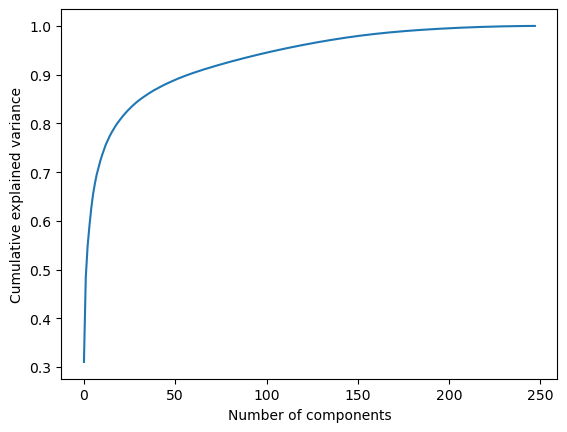

In [27]:
print(pca_248_ysamples.explained_variance_ratio_)
plt.plot(np.cumsum(pca_248_ysamples.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()


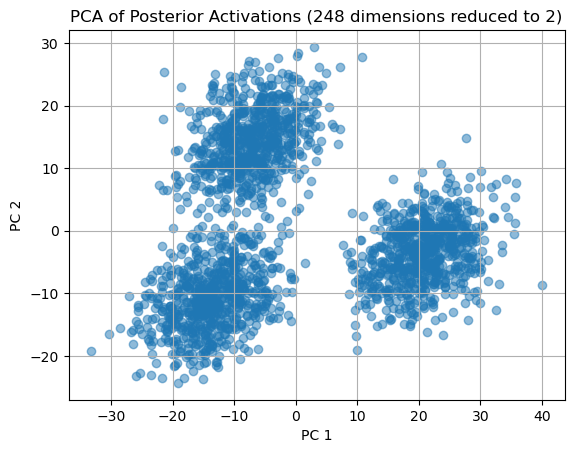

In [ ]:
# Apply PCA to reduce dimensionality from 248 to 2
pca_2_ysamples = PCA(n_components=2)  # Keep the top 2 principal components
YSamples_pca_2 = pca_2_ysamples.fit_transform(Y_centered_samples.T)  # Apply PCA and transform data (resulting shape: 2100 x 2)

# Y_pca now contains the 2100 observations in the reduced 2D space

#top 2 PC
plt.scatter(YSamples_pca_2[:, 0], YSamples_pca_2[:, 1], alpha=0.5)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('PCA of Posterior Activations (248 dimensions reduced to 2)')
plt.grid(True)
plt.show()

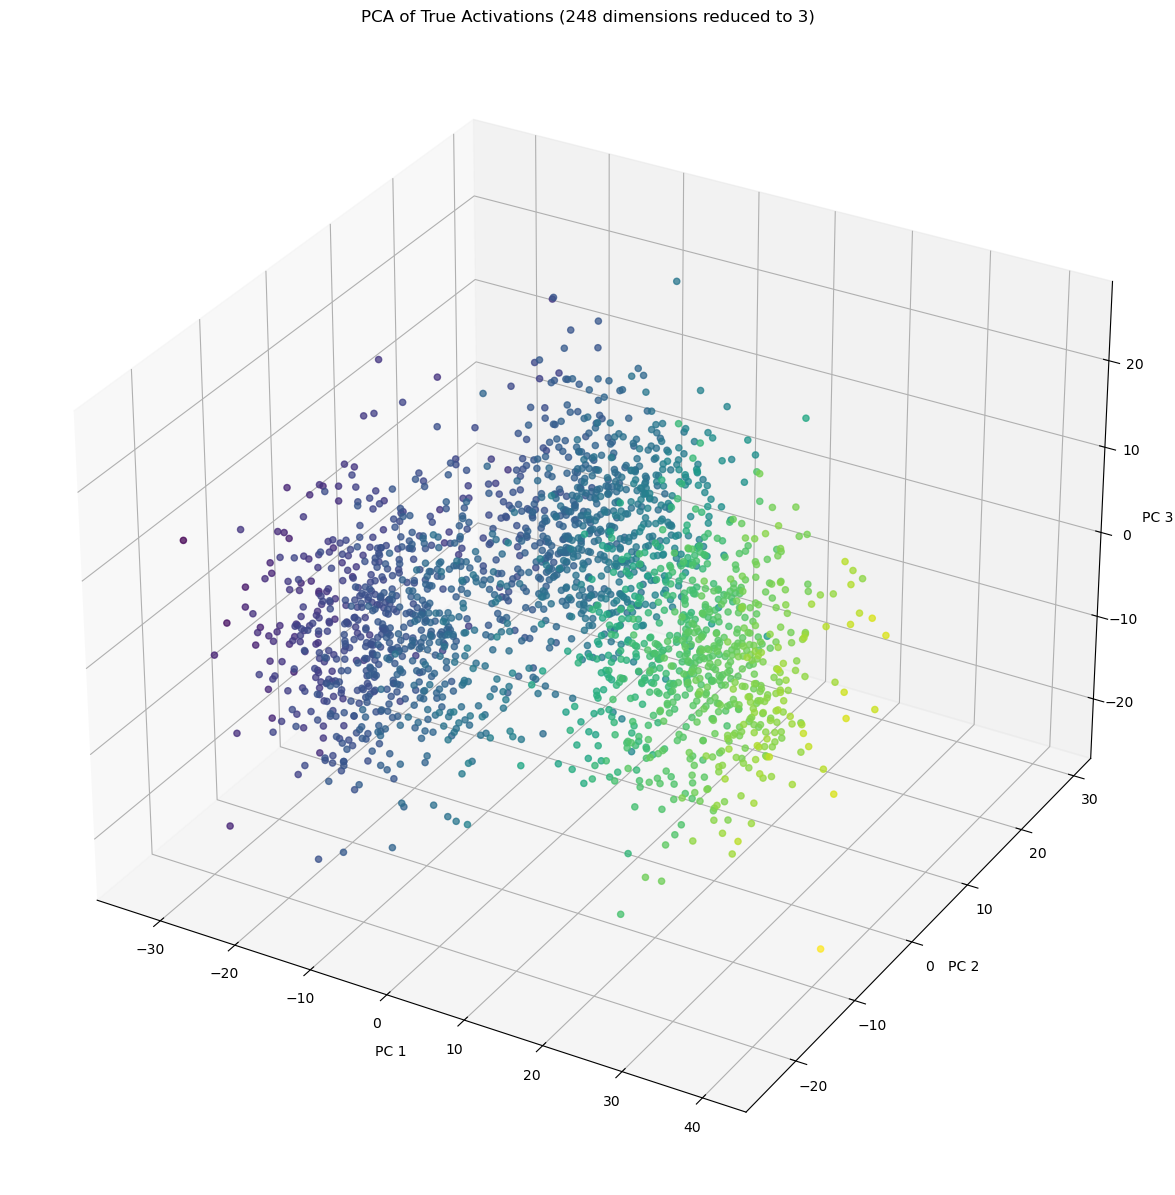

In [ ]:
pca_3_ysamples = PCA(n_components=3)
YSamples_pca_3 = pca_3_ysamples.fit_transform(Y_centered_samples.T)

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(YSamples_pca_3[:, 0], YSamples_pca_3[:, 1], YSamples_pca_3[:, 2],
           alpha=0.75, c=YSamples_pca_3[:, 0], cmap='viridis')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
plt.title('PCA of activations (248 → 3)')
plt.show()


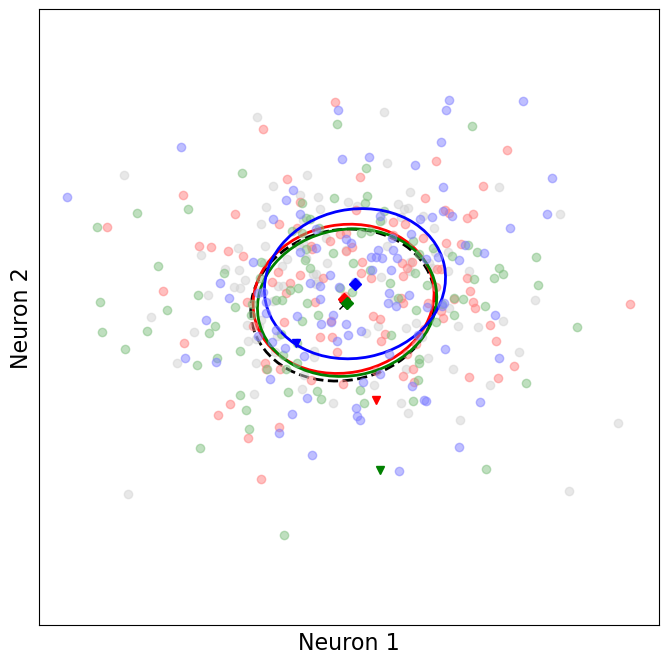

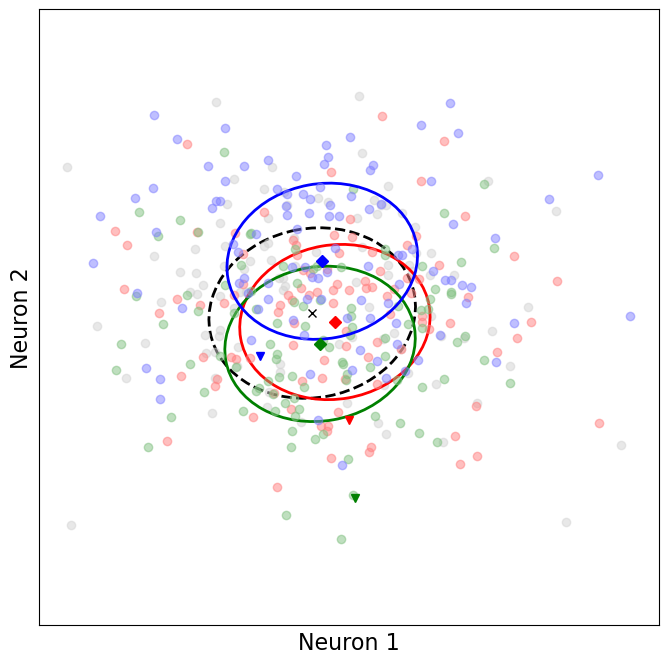

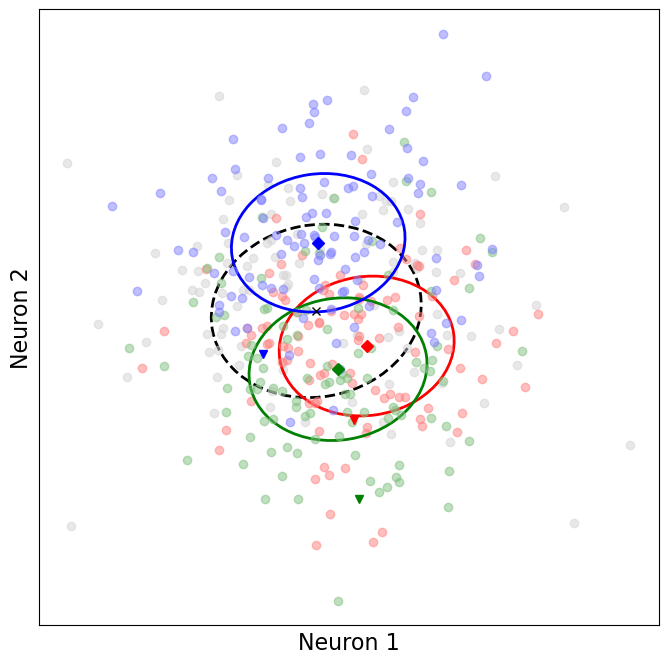

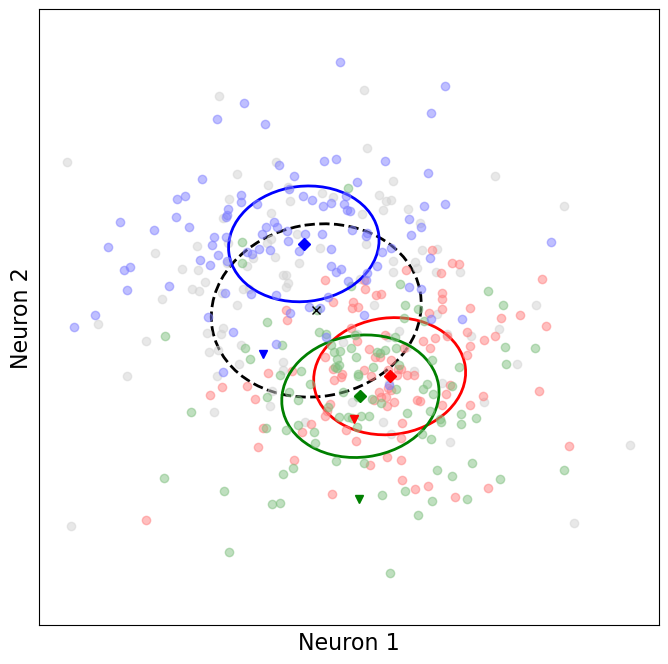

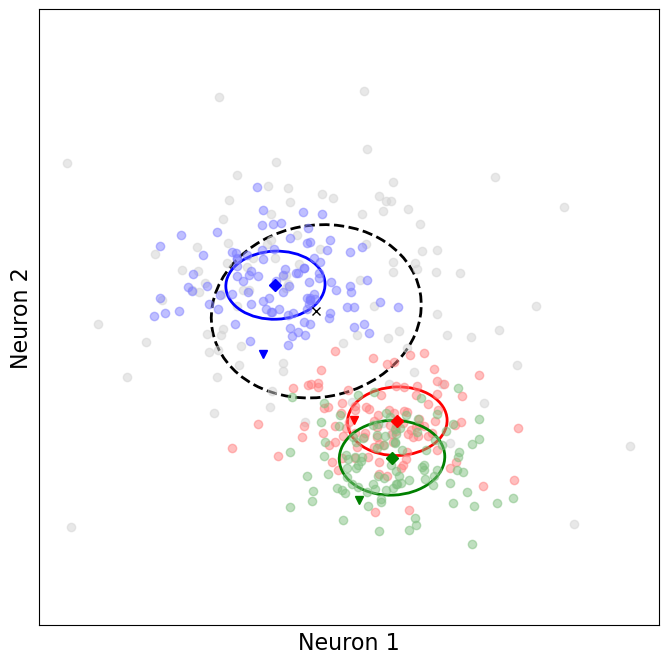

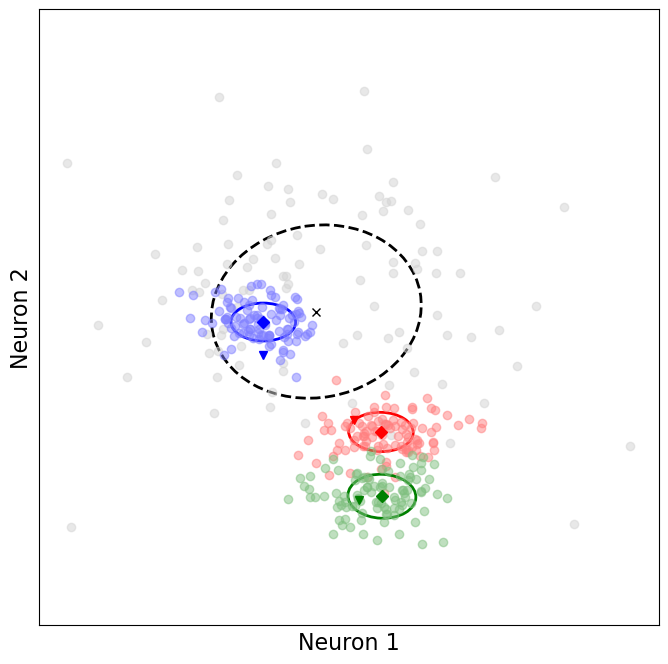

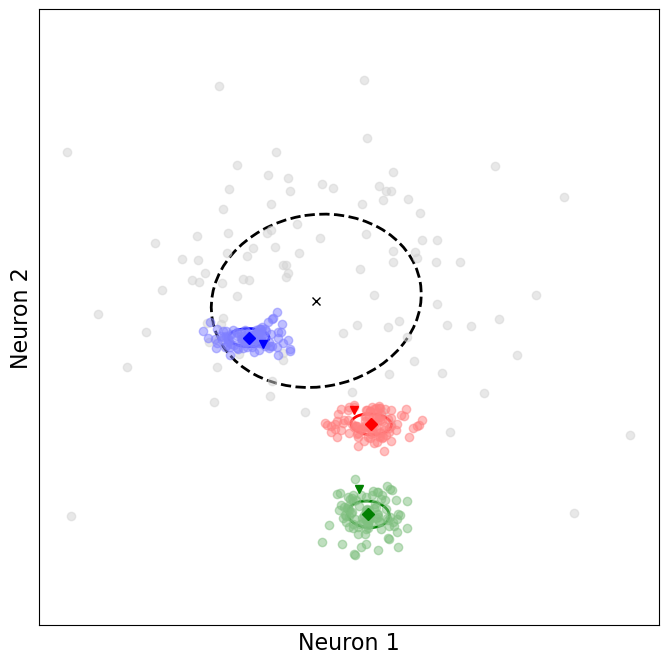

In [ ]:
for contrast_idx, z_contrast in enumerate(contrast_values):
    fig, ax = plt.subplots(figsize=(8, 8))

    plot_gaussian_ellipse(ax, mu_prior, rho_2d, edgecolor='black', linestyle='--')
    ax.plot(*mu_prior, 'kx')
    ax.scatter(samples_prior[:, 0], samples_prior[:, 1], color='lightgrey', alpha=0.5)

    for image_idx, (y_true, x_noise) in enumerate(zip(y_set, x_set)):
        x_obs = z_contrast * A @ y_true + x_noise
        mu, Sigma, Pz_x, zRange, dz = infer_y_and_z(x_obs, A, rho, kGam, thGam, sigmaX, Dz=100)

        # marginalise over z
        mu_yx = np.zeros(Dy)
        Sigma_yx = np.zeros((Dy, Dy))
        for zi in range(len(zRange)):
            mu_yx += Pz_x[zi] * mu[:, zi] * dz
        for zi in range(len(zRange)):
            diff = mu[:, zi] - mu_yx
            Sigma_yx += Pz_x[zi] * (Sigma[:, :, zi] + np.outer(diff, diff)) * dz

        mu_2d = mu_yx[neuron_indices]
        Sigma_2d = Sigma_yx[np.ix_(neuron_indices, neuron_indices)]

        plot_gaussian_ellipse(ax, mu_2d, Sigma_2d, edgecolor=colors[image_idx])
        ax.plot(mu_2d[0], mu_2d[1], marker='D', color=colors[image_idx])
        ax.plot(y_true[neuron_indices[0]], y_true[neuron_indices[1]], marker='v', color=colors[image_idx])

        samples_post = np.random.multivariate_normal(mu_2d, Sigma_2d, size=100)
        ax.scatter(samples_post[:, 0], samples_post[:, 1],
                   color=lighten_color(colors[image_idx], 0.5), alpha=0.5)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('Neuron 1', fontsize=16)
    ax.set_ylabel('Neuron 2', fontsize=16)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    plt.axis('equal')
    plt.grid(False)
    plt.show()

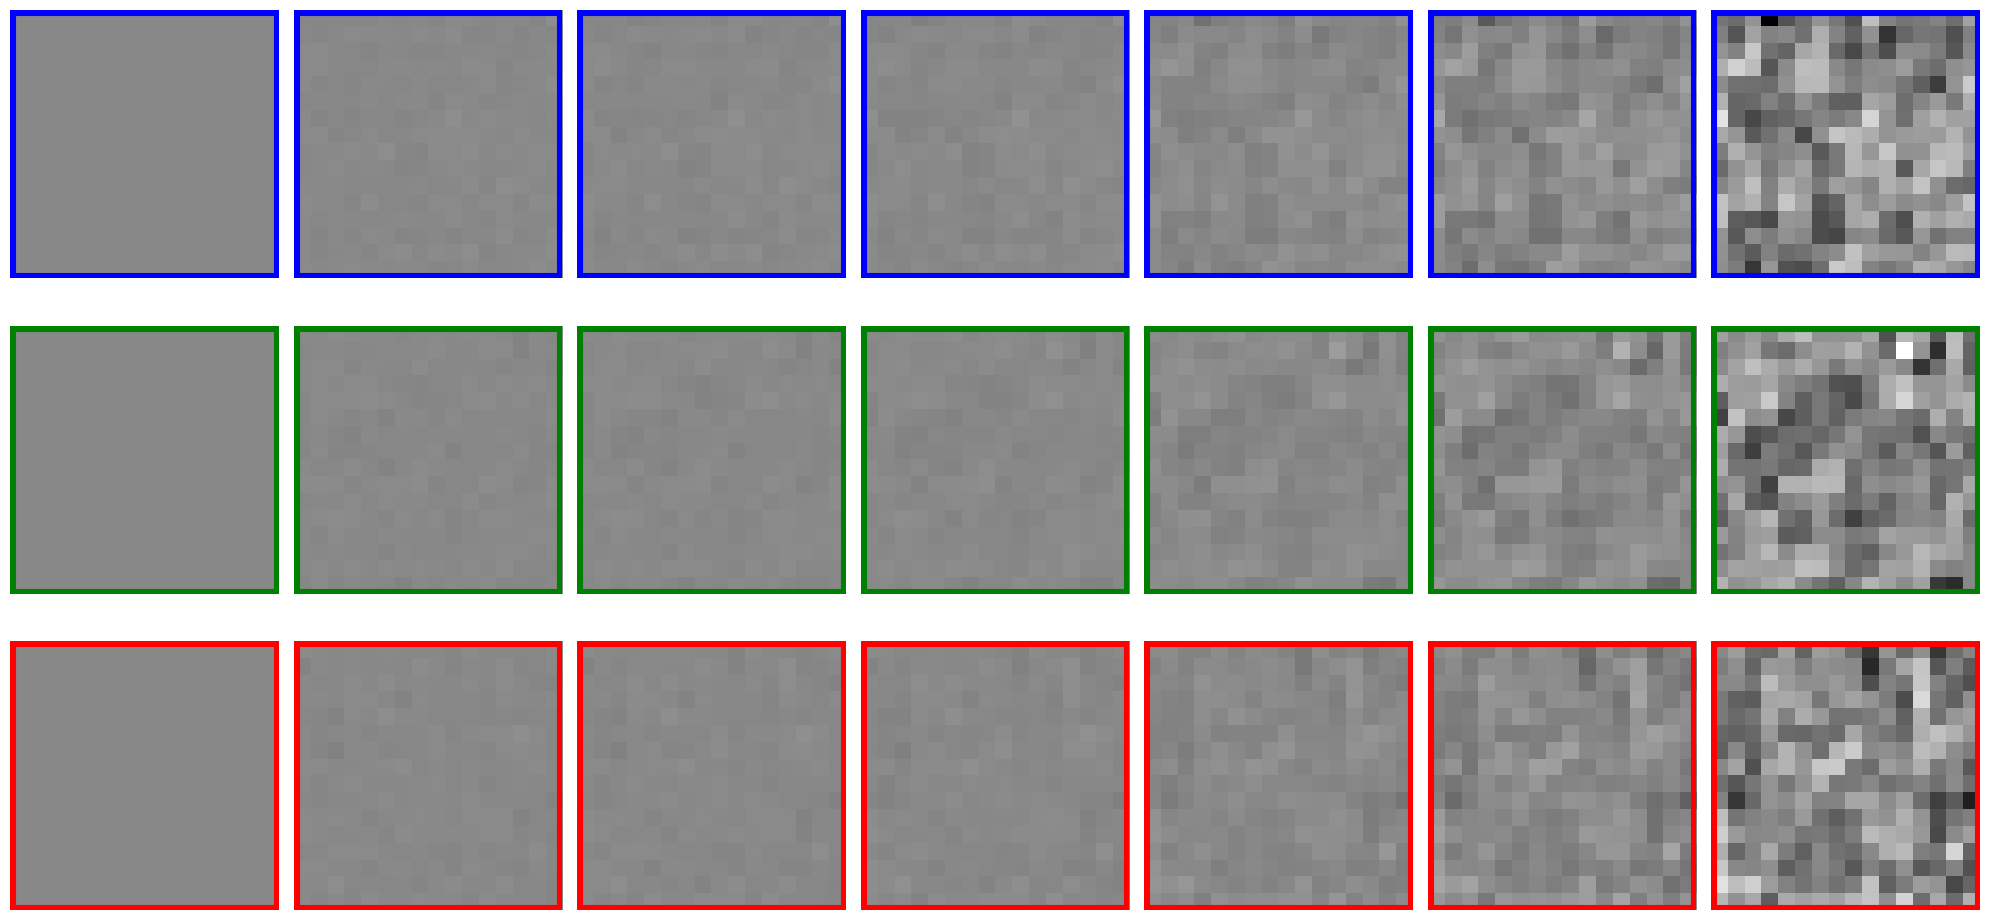

In [ ]:
import matplotlib.patches as patches

fig, axes = plt.subplots(3, 7, figsize=(20, 10))
border_colors = ['blue', 'green', 'red']

for row, (y, x) in enumerate(zip(y_set, x_set)):
    for col, z in enumerate(contrast_values):
        image = z * np.dot(A, y) + (x if z != 0 else 0)
        ax = axes[row, col]
        ax.imshow(image.reshape(16, 16), cmap='gray', vmin=min_val, vmax=max_val)
        ax.axis('off')

        rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                 linewidth=8, edgecolor=border_colors[row], facecolor='none')
        ax.add_patch(rect)

plt.tight_layout()
plt.show()

### REMAINING CODE AVAILABLE UPON REQUEST

nr490@cantab.ac.uk